### Majoreni BMU Participatory Mapping of Fishing Grounds and Identification of Seagrass Restoration Habitats 

<a href="https://colab.research.google.com/github/fredrick-AI4EO/Majoreni-Seagrass-Mapping/blob/main/majoreni.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
%pip install geolibre

In [30]:
from geolibre import Map

In [31]:
from IPython.display import IFrame

In [32]:

import leafmap
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

Reading the digitized fishing grounds polygons raw data, (vizualising the first two rows)

In [33]:
# Reading the digitized fishing grounds polygons and viz the first two rows
digitized_polys = ("../data/Majoreni_BMU_fishing_Grounds.geojson")
gdf = gpd.read_file(digitized_polys)
gdf.head(2)

,OGC_FID,OBJECTID,OID_,Name,SymbolID,AltMode,Base,Clamped,Extruded,Snippet,PopupInfo,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,0,1,0,Msojo,0,0,0,-1,0,None,None,0.013890,0.013890,0.000013,"POLYGON Z ((39.28359 -4.64683 0, 39.2817 -4.64..."
1,1,2,0,Mlimani,0,0,0,-1,0,None,None,0.022808,0.022808,0.000034,"POLYGON Z ((39.287 -4.64115 0, 39.28677 -4.639..."


In [34]:
# columns names check
gdf.columns

Index(['OGC_FID', 'OBJECTID', 'OID_', 'Name', 'SymbolID', 'AltMode', 'Base',
       'Clamped', 'Extruded', 'Snippet', 'PopupInfo', 'Shape_Leng',
       'Shape_Le_1', 'Shape_Area', 'geometry'],
      dtype='str')

Dropping/removal of unwanted columns

In [35]:
# Dropping/removal of unwanted columns
filtered = gdf.drop(columns=['OGC_FID', 'OID_', 'Snippet', 'SymbolID', 'Extruded'], inplace=True)
gdf

,OBJECTID,Name,AltMode,Base,Clamped,PopupInfo,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,1,Msojo,0,0,-1,None,0.013890,0.013890,1.348448e-05,"POLYGON Z ((39.28359 -4.64683 0, 39.2817 -4.64..."
1,2,Mlimani,0,0,-1,None,0.022808,0.022808,3.380987e-05,"POLYGON Z ((39.287 -4.64115 0, 39.28677 -4.639..."
2,3,Bumbu,0,0,-1,None,0.009028,0.009028,5.617641e-06,"POLYGON Z ((39.29895 -4.61394 0, 39.30047 -4.6..."
3,4,Bumbu_ya_nje,0,0,-1,None,0.013245,0.013245,1.155631e-05,"POLYGON Z ((39.30157 -4.63013 0, 39.30121 -4.6..."
4,5,Rekeoni,0,0,-1,None,0.002141,0.002141,3.049658e-07,"POLYGON Z ((39.2487 -4.58447 0, 39.24868 -4.58..."
5,6,Tunga,0,0,-1,None,0.003998,0.003998,1.020465e-06,"POLYGON Z ((39.25472 -4.58796 0, 39.25465 -4.5..."
6,7,Vijibweni,0,0,-1,None,0.003570,0.003570,9.302878e-07,"POLYGON Z ((39.26386 -4.58811 0, 39.26374 -4.5..."
7,8,Sii_ya_ndani,0,0,-1,None,0.019220,0.019220,2.001700e-05,"POLYGON Z ((39.26951 -4.63039 0, 39.27462 -4.6..."
8,9,Kifunguni,0,0,-1,None,0.021941,0.021941,3.311000e-05,"POLYGON Z ((39.27775 -4.63657 0, 39.27721 -4.6..."
9,10,Nyamani_ya_ndani,0,0,-1,None,0.014274,0.014274,1.421867e-05,"POLYGON Z ((39.29561 -4.63476 0, 39.29368 -4.6..."


Getting Polygon Boundaries and Centroids

In [36]:
# Boundary of each polygon
gdf["boundary"] = gdf.boundary

# centroid of each polygon
gdf["centroid"] = gdf.centroid
gdf.head(10)

,OBJECTID,Name,AltMode,Base,Clamped,PopupInfo,Shape_Leng,Shape_Le_1,Shape_Area,geometry,boundary,centroid
0,1,Msojo,0,0,-1,None,0.013890,0.013890,1.348448e-05,"POLYGON Z ((39.28359 -4.64683 0, 39.2817 -4.64...","LINESTRING Z (39.28359 -4.64683 0, 39.2817 -4....",POINT (39.28394 -4.64495)
1,2,Mlimani,0,0,-1,None,0.022808,0.022808,3.380987e-05,"POLYGON Z ((39.287 -4.64115 0, 39.28677 -4.639...","LINESTRING Z (39.287 -4.64115 0, 39.28677 -4.6...",POINT (39.28963 -4.64193)
2,3,Bumbu,0,0,-1,None,0.009028,0.009028,5.617641e-06,"POLYGON Z ((39.29895 -4.61394 0, 39.30047 -4.6...","LINESTRING Z (39.29895 -4.61394 0, 39.30047 -4...",POINT (39.30053 -4.61498)
3,4,Bumbu_ya_nje,0,0,-1,None,0.013245,0.013245,1.155631e-05,"POLYGON Z ((39.30157 -4.63013 0, 39.30121 -4.6...","LINESTRING Z (39.30157 -4.63013 0, 39.30121 -4...",POINT (39.30262 -4.62897)
4,5,Rekeoni,0,0,-1,None,0.002141,0.002141,3.049658e-07,"POLYGON Z ((39.2487 -4.58447 0, 39.24868 -4.58...","LINESTRING Z (39.2487 -4.58447 0, 39.24868 -4....",POINT (39.24892 -4.5844)
5,6,Tunga,0,0,-1,None,0.003998,0.003998,1.020465e-06,"POLYGON Z ((39.25472 -4.58796 0, 39.25465 -4.5...","LINESTRING Z (39.25472 -4.58796 0, 39.25465 -4...",POINT (39.25516 -4.58805)
6,7,Vijibweni,0,0,-1,None,0.003570,0.003570,9.302878e-07,"POLYGON Z ((39.26386 -4.58811 0, 39.26374 -4.5...","LINESTRING Z (39.26386 -4.58811 0, 39.26374 -4...",POINT (39.26422 -4.58769)
7,8,Sii_ya_ndani,0,0,-1,None,0.019220,0.019220,2.001700e-05,"POLYGON Z ((39.26951 -4.63039 0, 39.27462 -4.6...","LINESTRING Z (39.26951 -4.63039 0, 39.27462 -4...",POINT (39.27158 -4.63449)
8,9,Kifunguni,0,0,-1,None,0.021941,0.021941,3.311000e-05,"POLYGON Z ((39.27775 -4.63657 0, 39.27721 -4.6...","LINESTRING Z (39.27775 -4.63657 0, 39.27721 -4...",POINT (39.27998 -4.63481)
9,10,Nyamani_ya_ndani,0,0,-1,None,0.014274,0.014274,1.421867e-05,"POLYGON Z ((39.29561 -4.63476 0, 39.29368 -4.6...","LINESTRING Z (39.29561 -4.63476 0, 39.29368 -4...",POINT (39.29626 -4.63275)


In [47]:
# Area calculated here is for plotting purpose and does not represent the actual area coverage of the fishing grounds
gdf["area"] = gdf.area
gdf.head()

,OBJECTID,Name,AltMode,Base,Clamped,PopupInfo,Shape_Leng,Shape_Le_1,Shape_Area,geometry,area
0,1,Msojo,0,0,-1,None,0.013890,0.013890,1.348448e-05,"POLYGON Z ((39.28359 -4.64683 0, 39.2817 -4.64...",1.348448e-05
1,2,Mlimani,0,0,-1,None,0.022808,0.022808,3.380987e-05,"POLYGON Z ((39.287 -4.64115 0, 39.28677 -4.639...",3.380987e-05
2,3,Bumbu,0,0,-1,None,0.009028,0.009028,5.617641e-06,"POLYGON Z ((39.29895 -4.61394 0, 39.30047 -4.6...",5.617641e-06
3,4,Bumbu_ya_nje,0,0,-1,None,0.013245,0.013245,1.155631e-05,"POLYGON Z ((39.30157 -4.63013 0, 39.30121 -4.6...",1.155631e-05
4,5,Rekeoni,0,0,-1,None,0.002141,0.002141,3.049658e-07,"POLYGON Z ((39.2487 -4.58447 0, 39.24868 -4.58...",3.049658e-07


Responsive map to Interactively visualize the sites

In [51]:
explore_map = gdf.explore(basemap="HYBRID", 
            tooltip=["Name", "area"], 
            popup=True, 
            style_kwds=dict(weight=2, opacity=0.5)
            )

explore_map

In [53]:
explore_map.save("../outputs/html/gdf_explore.html")

Buffering Geometries

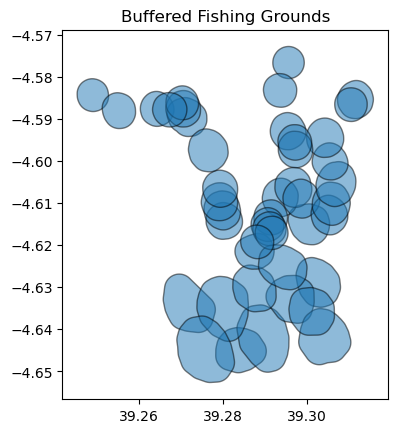

In [ ]:
gdf["buffered"] = gdf.buffer(0.0035)

gdf["buffered"].plot(alpha=0.5, edgecolor="black")
plt.title("Buffered Fishing Grounds")

plt.savefig(
    "../outputs/figures/buffered_fishing_grounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
gdf.columns 

Index(['OBJECTID', 'Name', 'AltMode', 'Base', 'Clamped', 'PopupInfo',
       'Shape_Leng', 'Shape_Le_1', 'Shape_Area', 'geometry', 'boundary',
       'centroid', 'area', 'buffered'],
      dtype='str')

In [41]:
# dropping columns for saving, workflows & machines compatibility
gdf.drop(columns=['boundary',
       'centroid', 'area', 'buffered'], inplace=True)

In [42]:
gdf

,OBJECTID,Name,AltMode,Base,Clamped,PopupInfo,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,1,Msojo,0,0,-1,None,0.013890,0.013890,1.348448e-05,"POLYGON Z ((39.28359 -4.64683 0, 39.2817 -4.64..."
1,2,Mlimani,0,0,-1,None,0.022808,0.022808,3.380987e-05,"POLYGON Z ((39.287 -4.64115 0, 39.28677 -4.639..."
2,3,Bumbu,0,0,-1,None,0.009028,0.009028,5.617641e-06,"POLYGON Z ((39.29895 -4.61394 0, 39.30047 -4.6..."
3,4,Bumbu_ya_nje,0,0,-1,None,0.013245,0.013245,1.155631e-05,"POLYGON Z ((39.30157 -4.63013 0, 39.30121 -4.6..."
4,5,Rekeoni,0,0,-1,None,0.002141,0.002141,3.049658e-07,"POLYGON Z ((39.2487 -4.58447 0, 39.24868 -4.58..."
5,6,Tunga,0,0,-1,None,0.003998,0.003998,1.020465e-06,"POLYGON Z ((39.25472 -4.58796 0, 39.25465 -4.5..."
6,7,Vijibweni,0,0,-1,None,0.003570,0.003570,9.302878e-07,"POLYGON Z ((39.26386 -4.58811 0, 39.26374 -4.5..."
7,8,Sii_ya_ndani,0,0,-1,None,0.019220,0.019220,2.001700e-05,"POLYGON Z ((39.26951 -4.63039 0, 39.27462 -4.6..."
8,9,Kifunguni,0,0,-1,None,0.021941,0.021941,3.311000e-05,"POLYGON Z ((39.27775 -4.63657 0, 39.27721 -4.6..."
9,10,Nyamani_ya_ndani,0,0,-1,None,0.014274,0.014274,1.421867e-05,"POLYGON Z ((39.29561 -4.63476 0, 39.29368 -4.6..."


In [ ]:
# unrun
gdf.to_file("outputs/Majoreni BMU Sites.geojson", driver="GeoJSON")

Interactively visualizing the data on GeoLibre cloud native GIS platform

In [ ]:
m = Map(center=[-4.60089383102632, 39.28702999617074])
m

In [54]:
m.to_html("../outputs/html/m_map.html")

Proposed Sites for Seagrass Restoration (In light green fill, and a solid red outline)

![alt text](proposed_sites.png)

Proposed seagrass restoration sites include: 
Kigomacha, Cheteni, Mbweni/ Vijibweni, Mrongani, Mafiga, and Kisumbike

sites' data available include Kigomacha, Cheteni, Mbweni/ Vijibweni.

These are within the green-filled polygons, with the distance between the sites calculated in the image below!


![alt text](Distance.png)

## Validation Data

Reading the Validation data (csv file)

In [45]:
# Reading (the first 15 rows) and converting the csv file into a GeoDataFrame
df = pd.read_csv("../data/Majoreni_fishing_grounds_points.csv")
gdf1 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]))
gdf1.head(15)

,Name,Latitude,Longitude,geometry
0,Makimatu,-4.576455,39.295517,POINT (39.29552 -4.57646)
1,Kifungu Mwandege,-4.583328,39.293303,POINT (39.2933 -4.58333)
2,Kulijani,-4.593122,39.295165,POINT (39.29516 -4.59312)
3,Kombeni,-4.595888,39.297312,POINT (39.29731 -4.59589)
4,Lekeoni,-4.597340,39.297637,POINT (39.29764 -4.59734)
5,Dimbwini,-4.586480,39.310457,POINT (39.31046 -4.58648)
6,Kijambani,-4.585645,39.311373,POINT (39.31137 -4.58564)
7,Kigomacha,-4.594115,39.304538,POINT (39.30454 -4.59412)
8,Vunguvunguni,-4.599947,39.305678,POINT (39.30568 -4.59995)
9,Jasimba,-4.605543,39.306937,POINT (39.30694 -4.60554)


Writing the validation data to a csv file

In [55]:
gdf1.to_csv("../data/validation_data.csv", index=False)

In [57]:
# Interactively visualizing the data as marker clusters on leafmap
m = leafmap.Map(center=[-4.60089383102632, 39.28702999617074], zoom=13)
m.add_basemap("HYBRID")
m.add_marker_cluster("../data/validation_data.csv", y="Latitude", x="Longitude", info_mode="on_click")
m

Map(center=[-4.60089383102632, 39.28702999617074], controls=(ZoomControl(options=['position', 'zoom_in_text', …

In [58]:
m.to_html("../outputs/html/validation_map.html")

In [59]:
gdf1

,Name,Latitude,Longitude,geometry
0,Makimatu,-4.576455,39.295517,POINT (39.29552 -4.57646)
1,Kifungu Mwandege,-4.583328,39.293303,POINT (39.2933 -4.58333)
2,Kulijani,-4.593122,39.295165,POINT (39.29516 -4.59312)
3,Kombeni,-4.595888,39.297312,POINT (39.29731 -4.59589)
4,Lekeoni,-4.597340,39.297637,POINT (39.29764 -4.59734)
5,Dimbwini,-4.586480,39.310457,POINT (39.31046 -4.58648)
6,Kijambani,-4.585645,39.311373,POINT (39.31137 -4.58564)
7,Kigomacha,-4.594115,39.304538,POINT (39.30454 -4.59412)
8,Vunguvunguni,-4.599947,39.305678,POINT (39.30568 -4.59995)
9,Jasimba,-4.605543,39.306937,POINT (39.30694 -4.60554)


Final output map 

![alt text](final_map-1.png)

A report on this exercise is available